# Optimal Transport via Hypernetworks

This notebook connects **hypernetworks** with **optimal transport** using the **Energy Distance** and **Wasserstein distance**.

## Key Idea

Given source distribution $P$ and target distribution $Q$, optimal transport seeks a map $T$ such that $T(X) \sim Q$ when $X \sim P$, while minimizing transport cost (e.g. $\mathbb{E}[\|X - T(X)\|^2]$ for $W_2$).

**Two-phase approach:**

1. **Phase 1 (Energy Distance Loss)**: Train the hypernetwork with pz frozen so that *every point in $P$ can predict every point in $Q$*. Each $z \sim p(z)$ induces a transport map $f_\phi(z)(\cdot)$. The EDL encourages the *ensemble* of predictions at each $x \in P$ to match the distribution $Q$—so the hypernetwork learns a family of transport maps that collectively cover $Q$.

2. **Phase 2 (L2 + pz optimization)**: Freeze $\phi$ and optimize $p(z)$. For **2D Gaussians**, the $W_2$ optimal transport map has a closed form (affine). We use $(x, T(x))$ pairs with $x \sim P$ and $T$ the analytical optimal map. Minimizing $\mathbb{E}_z[\|f_z(x) - T(x)\|^2]$ selects transport maps that align with the Wasserstein-2 optimum.

Together, EDL provides the expressive family of maps; pz optimization selects the one(s) that minimize the Wasserstein-2 distance.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP
from hnet.train.hnet import EnergyDistanceLoss
from matplotlib.lines import Line2D

%load_ext autoreload
%autoreload 2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

Using cuda


## 2D Two-Gaussian Dataset

Source $P \sim \mathcal{N}(\mu_P, \Sigma_P)$ and target $Q \sim \mathcal{N}(\mu_Q, \Sigma_Q)$. For 2D Gaussians with diagonal covariances, the $W_2$ optimal transport map is $T(x) = \mu_Q + \text{diag}(\sigma_Q / \sigma_P)(x - \mu_P)$.

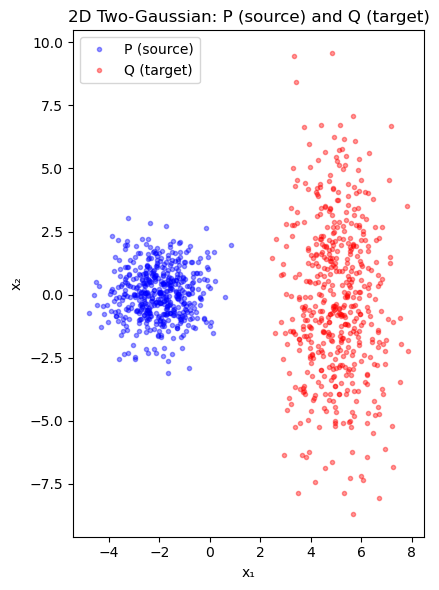

In [2]:
torch.manual_seed(42)
n_samples = 500

# P: source 2D Gaussian (diagonal cov)
mu_P = torch.tensor([-2.0, 0.0])
sigma_P = torch.tensor([1.0, 1.0])
# Q: target 2D Gaussian
mu_Q = torch.tensor([5.0, 0.0])
sigma_Q = torch.tensor([1, 3])

P = torch.randn(n_samples, 2) * sigma_P + mu_P
Q = torch.randn(n_samples, 2) * sigma_Q + mu_Q

# Optimal W2 map for diagonal Gaussians: T(x) = mu_Q + diag(sigma_Q/sigma_P)(x - mu_P)
def optimal_transport_map(x):
    return mu_Q + (sigma_Q / sigma_P) * (x - mu_P)

# Paired data for Phase 2: (x, T(x)) for x ~ P
Q_paired = optimal_transport_map(P)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.4, label='P (source)')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.4, label='Q (target)')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.set_aspect('equal')
ax.set_title('2D Two-Gaussian: P (source) and Q (target)')
plt.tight_layout()
plt.show()

## Phase 1: Train with Energy Distance Loss (pz frozen)

Train the hypernetwork so that for each $x \sim P$, the *ensemble* of predictions $\{f_{\phi}(z)(x) : z \sim p(z)\}$ matches the distribution $Q$. We sample $(x, y)$ with $x \sim P$ and $y \sim Q$; the EDL encourages the predicted distribution at $x$ to be close (in energy distance) to the target $y$. Over training, the ensemble learns to map any $x \in P$ into the support of $Q$.

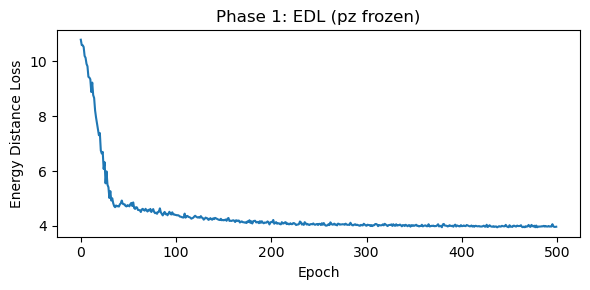

In [17]:
# Build model: maps x (2D) -> y (2D)
mlp = MLP(in_channels=2, out_channels=2, hidden_channels=64, layers=2, nonlin='elu', dropout=0., norm='none')

hnet = HyperNet(
    mlp,
    stochastic_channels=32,
    width=128,
    dropout=0., norm='none', bias=False,
    pz='normal',
    learn_pz=True,  # needed for Phase 2; we freeze the flow in Phase 1
    nvp_kwargs={'hidden_dim': 64, 'num_layers': 8, 'nonlin': 'elu', 'mask_type': 'alternating'},
).to(device)

# Freeze pz for Phase 1
for p in hnet.normalizing_flow.parameters():
    p.requires_grad = False

# Train with Energy Distance Loss: every point in P predicts every point in Q
optim = torch.optim.Adam(filter(lambda p: p.requires_grad, hnet.parameters()), lr=1e-4)
crit_edl = EnergyDistanceLoss()

batch_size, num_epochs, nsamples = 512, 500, 200
losses = []

for epoch in range(num_epochs):
    idx = torch.randperm(n_samples)[:batch_size]
    x_batch = P[idx].to(device)
    y_batch = Q[torch.randperm(n_samples)[:batch_size]].to(device)  # random pairing

    optim.zero_grad()
    yhat = hnet(x_batch, samples=nsamples)  # (nsamples, batch, 1)
    loss = crit_edl(yhat, y_batch)
    loss.backward()
    optim.step()
    losses.append(loss.item())
    print(f'Epoch {epoch}/{num_epochs}  EDL: {loss.item():.4f}', end='\r')

hnet = hnet.cpu()
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Energy Distance Loss')
plt.title('Phase 1: EDL (pz frozen)')
plt.tight_layout()
plt.show()

### Phase 1: Predicted transport

Sample many $z$ and plot the resulting transport maps $x \mapsto f_z(x)$. The ensemble should cover $Q$ when applied to points in $P$.

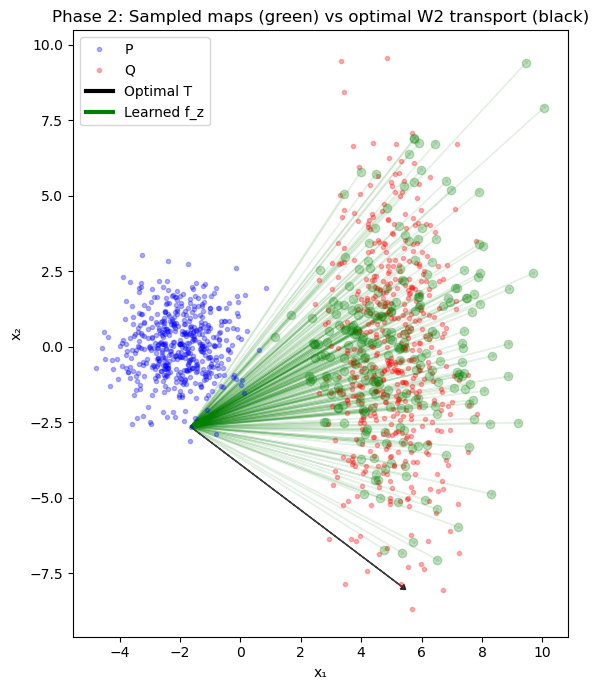

In [18]:
# import Line2D
from matplotlib.lines import Line2D

# Plot: transport maps after pz optimization vs optimal W2 map
hnet.eval()
n_show = 1
x_show = P[torch.randperm(n_samples)[:n_show]]
with torch.no_grad():
    yhat_pz = hnet(x_show, samples=250)  # (50, n_show, 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.3, label='P')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.3, label='Q')
x_np = x_show.numpy()
# Arrows: P -> learned transport (green) and optimal T(x) (black)
for i in range(n_show):
    preds = yhat_pz[:, i, :].numpy()
    t_opt = optimal_transport_map(x_show[i:i+1]).squeeze().numpy()
    ax.arrow(x_np[i, 0], x_np[i, 1], t_opt[0] - x_np[i, 0], t_opt[1] - x_np[i, 1],
             head_width=0.2, head_length=0.15, fc='black', ec='black', alpha=0.75)
    for j in range(len(preds)):
        ax.arrow(x_np[i, 0], x_np[i, 1], preds[j, 0] - x_np[i, 0], preds[j, 1] - x_np[i, 1],
                 head_width=0.12, head_length=0.08, fc='green', ec='green', alpha=0.1)
        plt.plot(preds[j, 0], preds[j, 1], 'go', alpha=0.25)
handles, labels = ax.get_legend_handles_labels()
handles.extend([Line2D([0], [0], color='black', lw=3, label='Optimal T'),
                Line2D([0], [0], color='green', lw=3, label='Learned f_z')])
ax.legend(handles=handles)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_aspect('equal')
ax.set_title('Phase 2: Sampled maps (green) vs optimal W2 transport (black)')
plt.tight_layout()
plt.show()

## Phase 2: Optimize pz to Minimize L2 (Wasserstein Connection)

Freeze $\phi$ and optimize $p(z)$. Use the **analytical optimal transport pairs** $(x, T(x))$ with $x \sim P$ and $T(x) = \mu_Q + \text{diag}(\sigma_Q/\sigma_P)(x - \mu_P)$. Minimize

$$\mathbb{E}_{z \sim p(z)}\left[\sum_i \|f_z(x_i) - T(x_i)\|^2\right]$$

This expected squared cost is the $W_2$ cost for the coupling induced by our stochastic map. By learning $p(z)$, we concentrate mass on the $z$ that produce transport maps closest to the Wasserstein-2 optimal transport.

Phase 2 epoch 200, L2 loss: 0.0589
Phase 2 epoch 400, L2 loss: 0.0341
Phase 2 epoch 600, L2 loss: 0.0406
Phase 2 epoch 800, L2 loss: 0.0162
Phase 2 epoch 1000, L2 loss: 0.0291


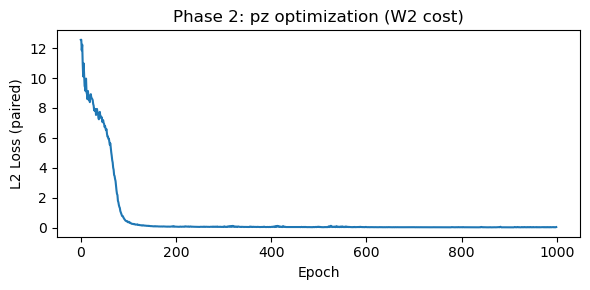

In [19]:
# Freeze phi, unfreeze pz
for p in hnet.f_phi.parameters():
    p.requires_grad = False
for p in hnet.normalizing_flow.parameters():
    p.requires_grad = True

# Paired data: (x, T(x)) for x ~ P (Q_paired already computed in Cell 3)
x_paired = P
y_paired = Q_paired

optim_pz = torch.optim.AdamW(hnet.normalizing_flow.parameters(), lr=5e-4, weight_decay=1e-6)
hnet = hnet.to(device)
x_paired_dev = x_paired.to(device)
y_paired_dev = y_paired.to(device)

losses_pz = []
batch_size_pz = 512
n_epochs_pz = 1000

for epoch in range(n_epochs_pz):
    idx = torch.randperm(n_samples)[:batch_size_pz]
    optim_pz.zero_grad()
    yhat = hnet(x_paired_dev[idx], samples=200)
    # L2: E[||f_z(x) - y||^2] over z
    loss = ((yhat - y_paired_dev[idx].unsqueeze(0)) ** 2).mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(hnet.parameters(), 1.0)
    optim_pz.step()
    losses_pz.append(loss.item())
    if (epoch + 1) % 200 == 0:
        print(f'Phase 2 epoch {epoch+1}, L2 loss: {loss.item():.4f}')

hnet = hnet.cpu()
plt.figure(figsize=(6, 3))
plt.plot(losses_pz)
plt.xlabel('Epoch')
plt.ylabel('L2 Loss (paired)')
plt.title('Phase 2: pz optimization (W2 cost)')
plt.tight_layout()
plt.show()

### Phase 2: Transport after pz optimization

After optimizing $p(z)$, the sampled transport maps should concentrate around the Wasserstein-2 optimal transport (affine map $T(x) = \mu_Q + \text{diag}(\sigma_Q/\sigma_P)(x - \mu_P)$).

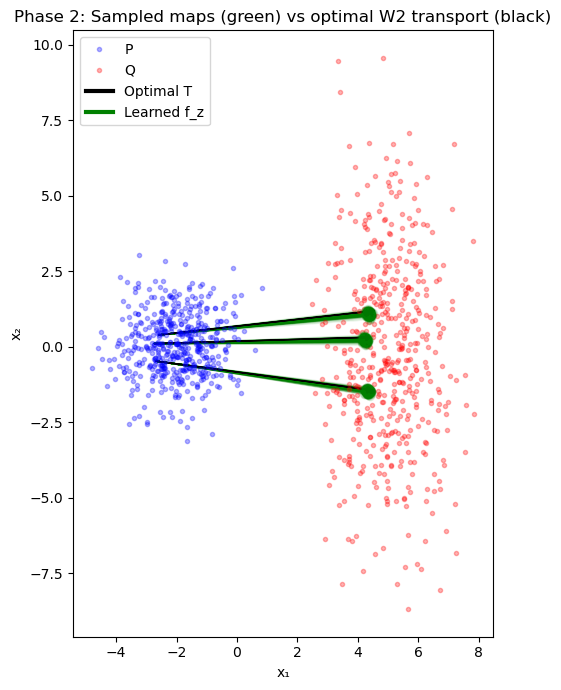

In [20]:
# import Line2D
from matplotlib.lines import Line2D

# Plot: transport maps after pz optimization vs optimal W2 map
hnet.eval()
n_show = 3
x_show = P[torch.randperm(n_samples)[:n_show]]
with torch.no_grad():
    yhat_pz = hnet(x_show, samples=250)  # (50, n_show, 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(P[:, 0].numpy(), P[:, 1].numpy(), 'b.', alpha=0.3, label='P')
ax.plot(Q[:, 0].numpy(), Q[:, 1].numpy(), 'r.', alpha=0.3, label='Q')
x_np = x_show.numpy()
# Arrows: P -> learned transport (green) and optimal T(x) (black)
for i in range(n_show):
    preds = yhat_pz[:, i, :].numpy()
    t_opt = optimal_transport_map(x_show[i:i+1]).squeeze().numpy()
    for j in range(len(preds)):
        ax.arrow(x_np[i, 0], x_np[i, 1], preds[j, 0] - x_np[i, 0], preds[j, 1] - x_np[i, 1],
                 head_width=0.12, head_length=0.08, fc='green', ec='green', alpha=0.05)
        plt.plot(preds[j, 0], preds[j, 1], 'go', alpha=0.1)
    ax.arrow(x_np[i, 0], x_np[i, 1], t_opt[0] - x_np[i, 0], t_opt[1] - x_np[i, 1],
             head_width=0.2, head_length=0.15, fc='black', ec='black', alpha=1.0)
handles, labels = ax.get_legend_handles_labels()
handles.extend([Line2D([0], [0], color='black', lw=3, label='Optimal T'),
                Line2D([0], [0], color='green', lw=3, label='Learned f_z')])
ax.legend(handles=handles)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_aspect('equal')
ax.set_title('Phase 2: Sampled maps (green) vs optimal W2 transport (black)')
plt.tight_layout()
plt.show()

## Quantifying Transport Quality

In [21]:
def L2(X_source, X_transported):
    """L2 transport cost of a paired map: sqrt(mean(||x - T(x)||^2))."""
    return float(np.sqrt(np.mean(np.sum((X_source - X_transported) ** 2, axis=-1))))


def mmd_rbf(X, Y, bandwidth=None):
    """Unbiased MMD² with RBF kernel between two (n, d) sample arrays.
    Bandwidth defaults to median pairwise distance in Y."""
    if bandwidth is None:
        dists = np.sqrt(np.sum((Y[:, None] - Y[None, :]) ** 2, axis=-1))
        bandwidth = float(np.median(dists[np.triu_indices(len(Y), k=1)]))
    def rbf(A, B):
        return np.exp(-np.sum((A[:, None] - B[None, :]) ** 2, axis=-1) / (2 * bandwidth ** 2))
    Kxx, Kyy, Kxy = rbf(X, X), rbf(Y, Y), rbf(X, Y)
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)
    n, m = len(X), len(Y)
    return float(Kxx.sum() / (n * (n - 1)) + Kyy.sum() / (m * (m - 1)) - 2 * Kxy.mean())


# Comparison to other Optimal Transport solvers

POT methods (EMD, Linear OT) fit a coupling to the **training** Q samples, so evaluating on the same Q is unfair — they effectively overfit to those samples. We evaluate all methods on a **held-out** `Q_test` for a fair comparison.

In [22]:
## If necessary, install POT
#!pip install POT 

In [25]:
import ot

P_np = P.detach().cpu().numpy()
Q_np = Q.detach().cpu().numpy()

# Held-out source and target — all methods trained on (P, Q), evaluated on (P_test, Q_test)
torch.manual_seed(999)
P_test = torch.randn(n_samples, 2) * sigma_P + mu_P
Q_test = (torch.randn(n_samples, 2) * sigma_Q + mu_Q).numpy()
P_test_np = P_test.numpy()

# --- Fit POT methods on (P, Q), transport P_test ---
transports = {
    'EMD': ot.da.EMDTransport(),
    'Linear OT': ot.da.LinearTransport(),
}
transported = {}
for name, t in transports.items():
    print(f'Fitting {name}...')
    t.fit(Xs=P_np, Xt=Q_np)
    transported[name] = t.transform(Xs=P_test_np)

transported['Optimal T*'] = optimal_transport_map(P_test).numpy()

# --- HNet on P_test ---
hnet.eval()
with torch.no_grad():
    Qhat_test = hnet(P_test, samples=100).detach().cpu().numpy()

# --- Evaluate all on Q_test ---
results = {}
for name, T in transported.items():
    results[name] = {'L2': L2(Q_test, T), 'MMD': mmd_rbf(T, Q_test)}

hnet_l2s, hnet_mmds = [], []
for i in range(len(Qhat_test)):
    print(f'\r  HNet {i+1}/{len(Qhat_test)}', end='')
    hnet_l2s.append(L2(Q_test, Qhat_test[i]))
    hnet_mmds.append(mmd_rbf(Qhat_test[i], Q_test))
print()

# --- Table ---
print(f'\n{"Method":<15} {"L2":>10} {"MMD²":>12}')
print('-' * 40)
for name, m in results.items():
    print(f'{name:<15} {m["L2"]:>10.4f} {m["MMD"]:>12.6f}')
print(f'{"HNet (mean)":<15} {np.mean(hnet_l2s):>10.4f} {np.mean(hnet_mmds):>12.6f}')



Fitting EMD...
Fitting Linear OT...
  HNet 100/100

Method                  L2         MMD²
----------------------------------------
EMD                 4.5897    -0.000290
Linear OT           4.5911    -0.000291
Optimal T*          4.5661    -0.001317
HNet (mean)         4.5883    -0.001271


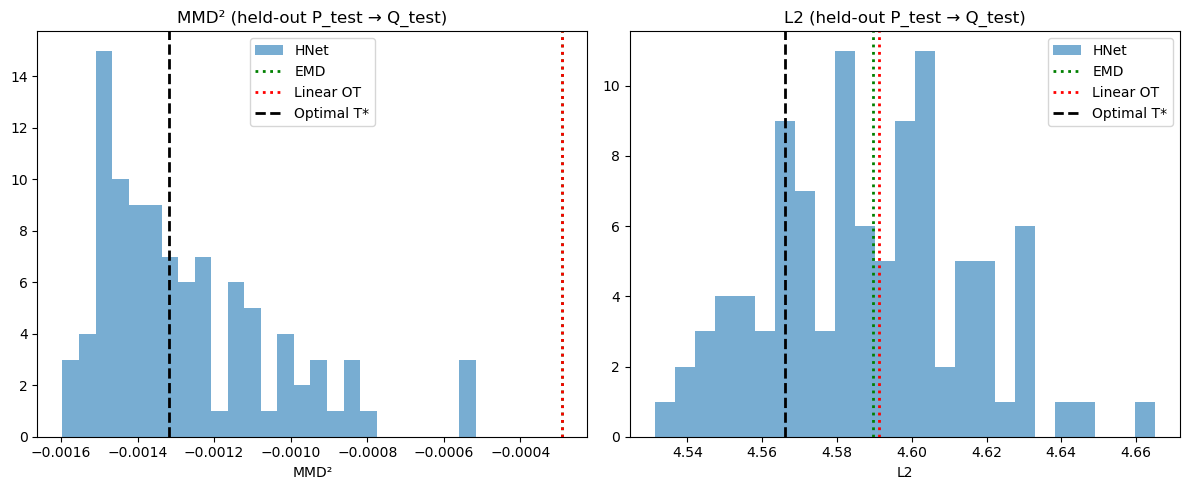

In [26]:
# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = {'EMD': 'green', 'Linear OT': 'red', 'Optimal T*': 'black'}
styles = {'EMD': ':', 'Linear OT': ':', 'Optimal T*': '--'}

for ax, hnet_vals, key, label in [(axes[0], hnet_mmds, 'MMD', 'MMD²'), (axes[1], hnet_l2s, 'L2', 'L2')]:
    ax.hist(hnet_vals, bins=25, alpha=0.6, label='HNet')
    for name, m in results.items():
        ax.axvline(x=m[key], color=colors[name], ls=styles[name], lw=2, label=name)
    ax.set_xlabel(label)
    ax.set_title(f'{label} (held-out P_test → Q_test)')
    ax.legend()

plt.tight_layout()
plt.show()

# HyperNet Transport Map Uncertainty Quantification 

One of the advantages of our HyperNetwork parameterized transport map is that we get uncertainty in the transport function. Let's evalulate how well it captures the uncertainty by using a reliability plot.

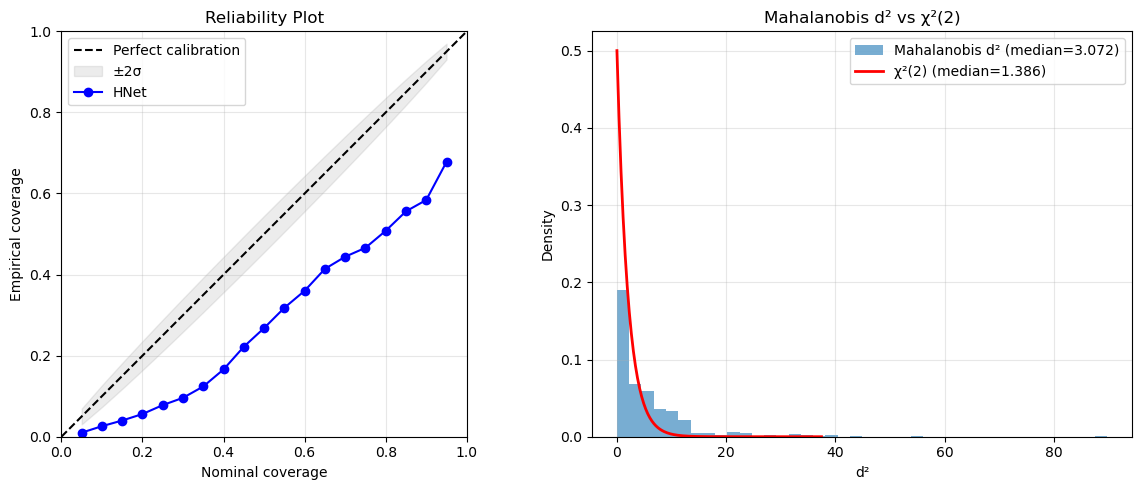

In [27]:
from scipy.stats import chi2

hnet.eval()
n_test = len(P_test)
K = 1000

T_star = optimal_transport_map(P_test[:n_test]).numpy()

with torch.no_grad():
    preds = hnet(P_test[:n_test], samples=K).numpy()  # (K, n_test, 2)

# Fit a 2D Gaussian per test point and compute Mahalanobis distance² of T*(x_i).
# Under correct calibration, d² ~ χ²(df=2).
d = preds.shape[-1]
mahal_sq = np.zeros(n_test)
for i in range(n_test):
    samples = preds[:, i, :]  # (K, d)
    mu = samples.mean(axis=0)
    cov = np.cov(samples.T) + 1e-6 * np.eye(d)
    diff = T_star[i] - mu
    mahal_sq[i] = diff @ np.linalg.solve(cov, diff)

# Nominal coverage α → χ²(2) threshold; empirical = fraction with d² ≤ threshold
alphas = np.linspace(0.05, 0.95, 19)
thresholds = chi2.ppf(alphas, df=d)
empirical = np.array([np.mean(mahal_sq <= t) for t in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: reliability plot
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
se = np.sqrt(alphas * (1 - alphas) / n_test)
ax.fill_between(alphas, alphas - 2*se, alphas + 2*se, alpha=0.15, color='gray', label='±2σ')
ax.plot(alphas, empirical, 'bo-', label='HNet')
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability Plot')
ax.legend()
ax.set_aspect('equal')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Right: Mahalanobis d² distribution vs theoretical χ²(2)
# If above-diagonal: d² values are much smaller than χ²(2) predicts,
# meaning bias (μ - T*) is tiny relative to predictive spread (Σ).
ax = axes[1]
x_chi2 = np.linspace(0, max(8, np.percentile(mahal_sq, 99)), 200)
ax.hist(mahal_sq, bins=40, density=True, alpha=0.6, label=f'Mahalanobis d² (median={np.median(mahal_sq):.3f})')
ax.plot(x_chi2, chi2.pdf(x_chi2, df=d), 'r-', lw=2, label=f'χ²({d}) (median={chi2.median(df=d):.3f})')
ax.set_xlabel('d²')
ax.set_ylabel('Density')
ax.set_title('Mahalanobis d² vs χ²(2)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()